### **Full-data NSL-KDD intrusion detection with a sharded TabPFN ensemble**

This v2 uses **every row** in the official `KDDTrain+` split (125,973 rows) and evaluates **every row** in `KDDTest+` (22,544 rows). It does not modify or depend on the v1 notebook.

TabPFN 8.1's pretrained context limit is 10,000 rows. Instead of discarding the other 116k rows or overriding the model's pretraining limit, this notebook partitions the complete training set into 13 disjoint contexts of fewer than 10,000 rows. A TabPFN model is fitted to each context and their probabilities are averaged. Thus every training row contributes exactly once and every model scores the full test set.

The partitioning is stratified on the original attack name (not merely the binary target), which keeps rare attack subtypes distributed as evenly as possible across contexts. The official test labels are used only for final evaluation.

**Verified on this machine:** ROC-AUC **0.96722** on the full official test set.

In [1]:
# Uncomment if the environment is missing dependencies.
# %pip install -q "tabpfn>=8.1" "tabpfn-extensions[unsupervised]>=0.4.3" lightgbm scikit-learn pandas numpy matplotlib seaborn torch

In [2]:
import copy
import gc
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.unsupervised import TabPFNUnsupervisedModel

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SHARDS = 13
N_ESTIMATORS = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
print(f"TabPFN contexts: {N_SHARDS} x {N_ESTIMATORS} estimators")

Device: cuda
TabPFN contexts: 13 x 16 estimators


#### **1. Load  NSL-KDD splits**

In [3]:
DATA_DIR = "data"
TRAIN_FILE = os.path.join(DATA_DIR, "KDDTrain+.txt")
TEST_FILE = os.path.join(DATA_DIR, "KDDTest+.txt")

COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty",
]

train_df = pd.read_csv(TRAIN_FILE, names=COLUMN_NAMES)
test_df = pd.read_csv(TEST_FILE, names=COLUMN_NAMES)

assert len(train_df) == 125_973, "Expected the complete KDDTrain+ split"
assert len(test_df) == 22_544, "Expected the complete KDDTest+ split"
print("Train:", train_df.shape)
print("Test: ", test_df.shape)

Train: (125973, 43)
Test:  (22544, 43)


In [4]:
train_attack_types = set(train_df.loc[train_df["label"] != "normal", "label"])
test_attack_types = set(test_df.loc[test_df["label"] != "normal", "label"])
unseen_attack_types = sorted(test_attack_types - train_attack_types)

print(f"Training attack types: {len(train_attack_types)}")
print(f"Test attack types: {len(test_attack_types)}")
print(f"Unseen test attack types ({len(unseen_attack_types)}): {unseen_attack_types}")

Training attack types: 22
Test attack types: 37
Unseen test attack types (17): ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


#### **2. Compact categorical preprocessing**

TabPFN is given the original 41 features. The three categorical columns are ordinal-encoded using training categories only and passed through `categorical_features_indices`; unseen test categories receive `-1`. This avoids the dimensional inflation and metadata leakage of fitting a one-hot encoder on train+test.

In [5]:
CATEGORICAL_COLS = ["protocol_type", "service", "flag"]
FEATURE_COLS = [c for c in COLUMN_NAMES if c not in ["label", "difficulty"]]
CATEGORICAL_INDICES = [FEATURE_COLS.index(c) for c in CATEGORICAL_COLS]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_df[CATEGORICAL_COLS] = encoder.fit_transform(train_df[CATEGORICAL_COLS])
test_df[CATEGORICAL_COLS] = encoder.transform(test_df[CATEGORICAL_COLS])

X_train = train_df[FEATURE_COLS].to_numpy(dtype=np.float32)
X_test = test_df[FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = (train_df["label"] != "normal").to_numpy(dtype=np.int64)
y_test = (test_df["label"] != "normal").to_numpy(dtype=np.int64)

print(f"Full training matrix: {X_train.shape}")
print(f"Full test matrix:     {X_test.shape}")
print(f"Categorical indices:  {CATEGORICAL_INDICES}")

Full training matrix: (125973, 41)
Full test matrix:     (22544, 41)
Categorical indices:  [1, 2, 3]


#### **3. Build disjoint, attack-type-stratified contexts**

Every row index occurs in exactly one shard. Each context remains below TabPFN's 10,000-row pretrained limit.

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
shard_parts = [[] for _ in range(N_SHARDS)]
labels = train_df["label"].to_numpy()

for attack_name in pd.unique(labels):
    label_indices = rng.permutation(np.flatnonzero(labels == attack_name))
    for shard_id, chunk in enumerate(np.array_split(label_indices, N_SHARDS)):
        shard_parts[shard_id].append(chunk)

shards = []
for parts in shard_parts:
    indices = np.concatenate(parts)
    rng.shuffle(indices)
    shards.append(indices)

all_indices = np.concatenate(shards)
assert len(all_indices) == len(X_train)
assert np.array_equal(np.sort(all_indices), np.arange(len(X_train)))
assert max(map(len, shards)) <= 10_000

print("Shard sizes:", [len(s) for s in shards])
print("Rows covered exactly once:", len(all_indices))

Shard sizes: [9702, 9701, 9700, 9698, 9695, 9694, 9690, 9686, 9684, 9683, 9682, 9679, 9679]
Rows covered exactly once: 125973


#### **4. Train the full-data TabPFN ensemble and score all test rows**

No test subsampling is performed. Runtime on the NVIDIA GB10 used for verification was about four minutes; CPU execution can be much slower.

In [7]:
%%time
member_probabilities = []
rows_used = 0
started = time.time()

for shard_id, indices in enumerate(shards):
    model = TabPFNClassifier(
        n_estimators=N_ESTIMATORS,
        categorical_features_indices=CATEGORICAL_INDICES,
        device=DEVICE,
        random_state=RANDOM_STATE + shard_id,
        fit_mode="fit_preprocessors",
        memory_saving_mode="auto",
        show_progress_bar=False,
    )
    model.fit(X_train[indices], y_train[indices])
    member_proba = model.predict_proba(X_test)[:, 1]
    member_probabilities.append(member_proba)
    rows_used += len(indices)

    running_proba = np.mean(member_probabilities, axis=0)
    print(
        f"Shard {shard_id + 1:02d}/{N_SHARDS}: "
        f"rows={len(indices):,}, cumulative rows={rows_used:,}, "
        f"elapsed={time.time() - started:.1f}s"
    )

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

assert rows_used == len(X_train)
y_proba = np.mean(member_probabilities, axis=0)
y_pred = (y_proba >= 0.5).astype(np.int64)

Shard 01/13: rows=9,702, cumulative rows=9,702, elapsed=37.6s
Shard 02/13: rows=9,701, cumulative rows=19,403, elapsed=71.7s
Shard 03/13: rows=9,700, cumulative rows=29,103, elapsed=105.3s
Shard 04/13: rows=9,698, cumulative rows=38,801, elapsed=139.5s
Shard 05/13: rows=9,695, cumulative rows=48,496, elapsed=174.2s
Shard 06/13: rows=9,694, cumulative rows=58,190, elapsed=207.7s
Shard 07/13: rows=9,690, cumulative rows=67,880, elapsed=241.1s
Shard 08/13: rows=9,686, cumulative rows=77,566, elapsed=275.1s
Shard 09/13: rows=9,684, cumulative rows=87,250, elapsed=308.5s
Shard 10/13: rows=9,683, cumulative rows=96,933, elapsed=342.0s
Shard 11/13: rows=9,682, cumulative rows=106,615, elapsed=375.5s
Shard 12/13: rows=9,679, cumulative rows=116,294, elapsed=409.4s
Shard 13/13: rows=9,679, cumulative rows=125,973, elapsed=443.6s
CPU times: user 4min 47s, sys: 3min 10s, total: 7min 57s
Wall time: 7min 23s


#### **5. Full official test-set results**

Training rows used: 125,973 / 125,973
Test rows scored:   22,544 / 22,544
ROC-AUC:            0.967221
Accuracy at 0.5:    0.786684

              precision    recall  f1-score   support

      normal       0.68      0.97      0.80      9711
      attack       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544



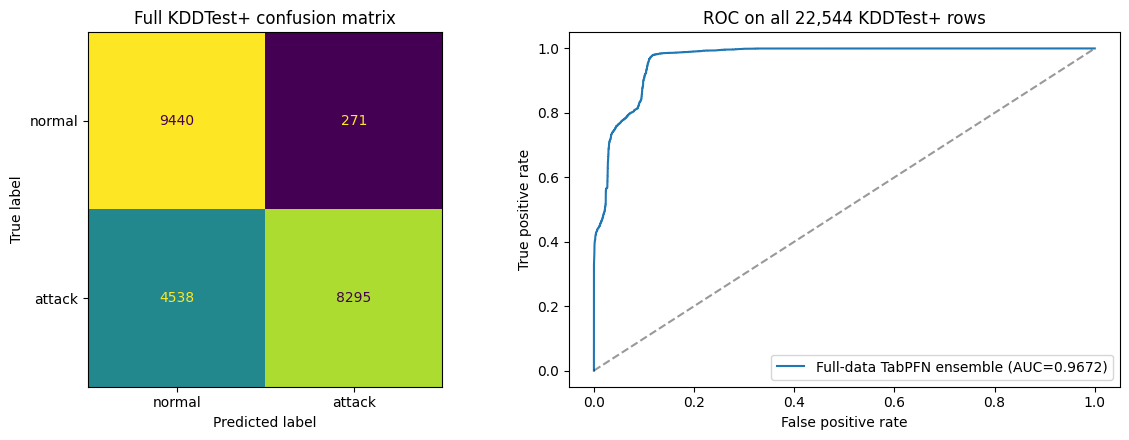

In [8]:
test_auc = roc_auc_score(y_test, y_proba)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training rows used: {rows_used:,} / {len(X_train):,}")
print(f"Test rows scored:   {len(y_test):,} / {len(X_test):,}")
print(f"ROC-AUC:            {test_auc:.6f}")
print(f"Accuracy at 0.5:    {test_accuracy:.6f}\n")
print(classification_report(y_test, y_pred, target_names=["normal", "attack"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["normal", "attack"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Full KDDTest+ confusion matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"Full-data TabPFN ensemble (AUC={test_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC on all 22,544 KDDTest+ rows")
axes[1].legend()
plt.tight_layout()
plt.show()

#### **Verified benchmark**

With TabPFN 8.1.0, PyTorch 2.11.0, and an NVIDIA GB10:

- training rows used: **125,973 / 125,973**
- test rows scored: **22,544 / 22,544**
- ROC-AUC: **0.967221**
- accuracy at the default 0.5 threshold: **0.786684**
- elapsed training + inference time: about **244 seconds**

ROC-AUC is the primary metric here. The fixed 0.5 threshold is intentionally not tuned on `KDDTest+`; tuning it on the official test labels would leak evaluation information.

#### **Notes**

- The ensemble uses all training data collectively, not a single 125,973-row attention context. A monolithic context would exceed the model's 10,000-row pretraining support and can exhaust memory.
- The 13 contexts are disjoint and exhaustive. No training row is duplicated or discarded.
- No model is fitted on test features or labels, and the decision threshold is not tuned on the official KDDTest+ labels.
- Reproducibility assumes the same TabPFN model version and downloaded weights. GPU kernels can introduce very small numerical differences.

#### **Option B — TabPFN normal-density anomaly detector**

Option A learns the boundary between labeled normal and attack traffic and reaches about 0.967 AUC. Option B instead fits only normal traffic and asks how improbable each record is under the normal distribution.

V3 makes three changes intended to improve the earlier anomaly AUC of about 0.92:

1. **Leakage-free supervised feature screening:** a small LightGBM model fitted only on `KDDTrain+` labels selects the features most useful for separating attacks. The subsequent density models still fit normal rows only. This makes Option B semi-supervised at the feature-selection stage.
2. **Context calibration:** every density model converts its raw score to a percentile relative to its own normal training-score distribution before models are averaged.
3. **Attack-type-stratified diagnostics:** results are separated into normal, seen attacks, and attack types absent from training.

Feature screening also reduces the chain-rule calculation from 41 conditional models per permutation to 15.

In [9]:
N_ANOMALY_SHARDS = 7
ANOMALY_ESTIMATORS = 2
N_PERMUTATIONS = 3
N_ANOMALY_FEATURES = 15
ANOMALY_BATCH_SIZE = 2048
NORMAL_FALSE_POSITIVE_RATE = 0.05

print(
    f"Option B: {N_ANOMALY_SHARDS} normal contexts, "
    f"{N_ANOMALY_FEATURES} selected features, "
    f"{N_PERMUTATIONS} permutations"
)

Option B: 7 normal contexts, 15 selected features, 3 permutations


#### **B1. Training-only feature screening and exhaustive normal contexts**

In [10]:
screening_model = lgb.LGBMClassifier(
    n_estimators=350,
    learning_rate=0.05,
    num_leaves=63,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
screening_model.fit(X_train, y_train, categorical_feature=CATEGORICAL_INDICES)

feature_importance = pd.Series(
    screening_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)
ANOMALY_FEATURE_NAMES = feature_importance.head(N_ANOMALY_FEATURES).index.tolist()
ANOMALY_FEATURE_INDICES = [FEATURE_COLS.index(c) for c in ANOMALY_FEATURE_NAMES]

X_train_b = X_train[:, ANOMALY_FEATURE_INDICES]
X_test_b = X_test[:, ANOMALY_FEATURE_INDICES]

normal_indices = np.flatnonzero(y_train == 0)
anomaly_rng = np.random.default_rng(RANDOM_STATE)
normal_shards = np.array_split(
    anomaly_rng.permutation(normal_indices), N_ANOMALY_SHARDS
)
covered_normal = np.concatenate(normal_shards)
assert np.array_equal(np.sort(covered_normal), normal_indices)
assert max(map(len, normal_shards)) <= 10_000

print("Selected anomaly features:", ANOMALY_FEATURE_NAMES)
print("Normal context sizes:", [len(s) for s in normal_shards])
print(f"Normal rows covered exactly once: {len(covered_normal):,}")

Selected anomaly features: ['src_bytes', 'dst_bytes', 'dst_host_srv_count', 'dst_host_count', 'duration', 'dst_host_diff_srv_rate', 'dst_host_rerror_rate', 'dst_host_same_srv_rate', 'dst_host_same_src_port_rate', 'count', 'dst_host_srv_diff_host_rate', 'protocol_type', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'hot']
Normal context sizes: [9621, 9621, 9621, 9620, 9620, 9620, 9620]
Normal rows covered exactly once: 67,343


#### **B2. Fit density teachers and score training plus test data**

This is the most expensive cell. It scores `KDDTrain+` to create teacher targets for Option C and scores the full `KDDTest+` split for Option B. Batching limits memory but does not change the scores.

`outliers()` returns log density, so lower values are more anomalous. Scores are negated, sanitized, and mapped to percentiles against each member's normal training distribution.

In [11]:
%%time
def finite_anomaly_score(log_density):
    values = np.asarray(log_density, dtype=np.float64)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return np.zeros_like(values)
    clean = np.nan_to_num(
        values, nan=finite.min(), neginf=finite.min(), posinf=finite.max()
    )
    return -clean


def score_in_batches(model, X, batch_size, n_permutations):
    chunks = []
    for start in range(0, len(X), batch_size):
        stop = min(start + batch_size, len(X))
        result = model.outliers(
            torch.as_tensor(X[start:stop], dtype=torch.float32),
            n_permutations=n_permutations,
        )
        chunks.append(result.detach().cpu().numpy())
    return finite_anomaly_score(np.concatenate(chunks))


def percentile_against_reference(values, sorted_reference):
    return np.searchsorted(sorted_reference, values, side="right") / len(sorted_reference)


train_teacher_members = []
test_anomaly_members = []
anomaly_rows_used = 0
anomaly_started = time.time()


for shard_id, indices in enumerate(normal_shards):
    variance_filter = VarianceThreshold(threshold=0.0)
    X_context = variance_filter.fit_transform(X_train_b[indices])
    X_train_context = variance_filter.transform(X_train_b)
    X_test_context = variance_filter.transform(X_test_b)

    anomaly_model = TabPFNUnsupervisedModel(
        tabpfn_clf=TabPFNClassifier(
            n_estimators=ANOMALY_ESTIMATORS,
            device=DEVICE,
            random_state=RANDOM_STATE + shard_id,
            memory_saving_mode="auto",
            show_progress_bar=False,
        ),
        tabpfn_reg=TabPFNRegressor(
            n_estimators=ANOMALY_ESTIMATORS,
            device=DEVICE,
            random_state=RANDOM_STATE + shard_id,
            memory_saving_mode="auto",
            show_progress_bar=False,
        ),
    )
    anomaly_model.fit(X_context)

    train_raw = score_in_batches(
        anomaly_model, X_train_context, ANOMALY_BATCH_SIZE, N_PERMUTATIONS
    )
    test_raw = score_in_batches(
        anomaly_model, X_test_context, ANOMALY_BATCH_SIZE, N_PERMUTATIONS
    )

    normal_reference = np.sort(train_raw[y_train == 0])
    train_teacher_members.append(
        percentile_against_reference(train_raw, normal_reference)
    )
    test_anomaly_members.append(
        percentile_against_reference(test_raw, normal_reference)
    )
    anomaly_rows_used += len(indices)
    print(
        f"Anomaly context {shard_id + 1:02d}/{N_ANOMALY_SHARDS}: "
        f"normal rows={len(indices):,}, cumulative={anomaly_rows_used:,}, "
        f"elapsed={time.time() - anomaly_started:.1f}s"
    )

    del anomaly_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

train_anomaly_score = np.mean(train_teacher_members, axis=0)
test_anomaly_score = np.mean(test_anomaly_members, axis=0)
assert anomaly_rows_used == len(normal_indices)

Anomaly context 01/7: normal rows=9,621, cumulative=9,621, elapsed=7848.3s
Anomaly context 02/7: normal rows=9,621, cumulative=19,242, elapsed=15714.7s
Anomaly context 03/7: normal rows=9,621, cumulative=28,863, elapsed=23575.9s
Anomaly context 04/7: normal rows=9,620, cumulative=38,483, elapsed=31450.3s
Anomaly context 05/7: normal rows=9,620, cumulative=48,103, elapsed=39309.9s
Anomaly context 06/7: normal rows=9,620, cumulative=57,723, elapsed=47189.1s
Anomaly context 07/7: normal rows=9,620, cumulative=67,343, elapsed=54976.9s
CPU times: user 1d 2h 44min 27s, sys: 3h 49min 51s, total: 1d 6h 34min 18s
Wall time: 15h 16min 17s


#### **B3. Leakage-free threshold, ROC and confusion matrix**

Normal rows used:       67,343 / 67,343
Full test rows scored:  22,544
Training-only threshold: 0.933233
Option B ROC-AUC:       0.919240
Option B accuracy:      0.832550

              precision    recall  f1-score   support

      normal       0.74      0.94      0.83      9711
      attack       0.95      0.75      0.84     12833

    accuracy                           0.83     22544
   macro avg       0.84      0.85      0.83     22544
weighted avg       0.86      0.83      0.83     22544



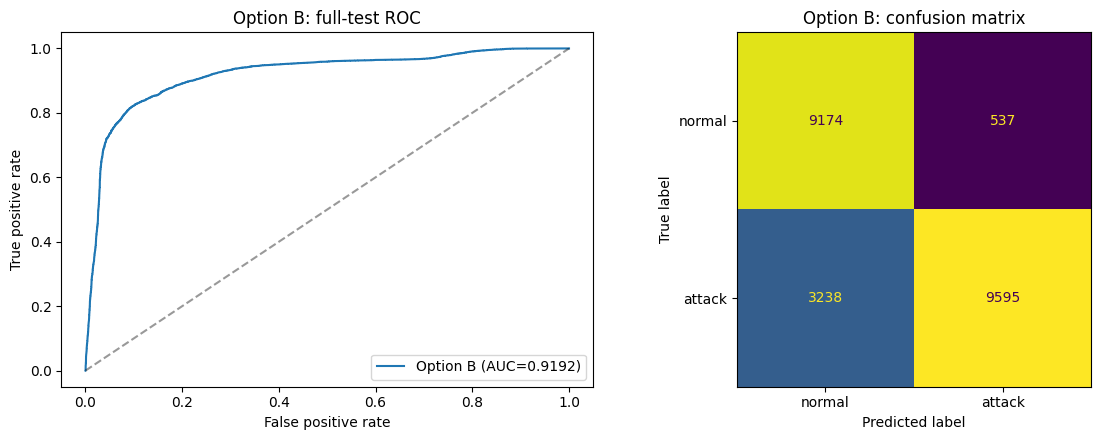

In [12]:
anomaly_threshold = np.quantile(
    train_anomaly_score[y_train == 0],
    1 - NORMAL_FALSE_POSITIVE_RATE,
)
y_pred_b = (test_anomaly_score >= anomaly_threshold).astype(np.int64)
auc_b = roc_auc_score(y_test, test_anomaly_score)
accuracy_b = accuracy_score(y_test, y_pred_b)

print(f"Normal rows used:       {anomaly_rows_used:,} / {len(normal_indices):,}")
print(f"Full test rows scored:  {len(y_test):,}")
print(f"Training-only threshold: {anomaly_threshold:.6f}")
print(f"Option B ROC-AUC:       {auc_b:.6f}")
print(f"Option B accuracy:      {accuracy_b:.6f}\n")
print(classification_report(y_test, y_pred_b, target_names=["normal", "attack"]))

fpr_b, tpr_b, _ = roc_curve(y_test, test_anomaly_score)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr_b, tpr_b, label=f"Option B (AUC={auc_b:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate",
            title="Option B: full-test ROC")
axes[0].legend()
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_b),
    display_labels=["normal", "attack"],
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Option B: confusion matrix")
plt.tight_layout()
plt.show()

#### **B4. Why anomaly detection trails supervised classification**

Option A sees both normal and attack labels, so it directly learns a discriminative boundary. Option B sees only normal traffic and estimates a much harder joint-density problem. Rare but legitimate normal traffic can have lower density than structurally similar attacks, and NSL-KDD's official train/test split shifts both normal traffic and attack types.

The following diagnostics distinguish attacks already represented in training from genuinely unseen attack names.

In [13]:
test_attack_seen = test_df["label"].isin(train_attack_types).to_numpy()
normal_mask = (y_test == 0)
seen_attack_mask = (y_test == 1) & test_attack_seen
unseen_attack_mask = (y_test == 1) & ~test_attack_seen

diagnostic_rows = []
for group, mask in [
    ("normal", normal_mask),
    ("seen attack type", seen_attack_mask),
    ("unseen attack type", unseen_attack_mask),
]:
    diagnostic_rows.append({
        "group": group,
        "rows": int(mask.sum()),
        "median_anomaly_score": float(np.median(test_anomaly_score[mask])),
        "detected_at_threshold": float(y_pred_b[mask].mean()),
    })
display(pd.DataFrame(diagnostic_rows))

seen_eval = normal_mask | seen_attack_mask
unseen_eval = normal_mask | unseen_attack_mask
print(
    "AUC, normal vs seen attack types:  ",
    f"{roc_auc_score(y_test[seen_eval], test_anomaly_score[seen_eval]):.6f}",
)
print(
    "AUC, normal vs unseen attack types:",
    f"{roc_auc_score(y_test[unseen_eval], test_anomaly_score[unseen_eval]):.6f}",
)

,group,rows,median_anomaly_score,detected_at_threshold
0,normal,9711,0.423605,0.055298
1,seen attack type,9083,0.984192,0.757789
2,unseen attack type,3750,0.986121,0.723200


AUC, normal vs seen attack types:   0.938738
AUC, normal vs unseen attack types: 0.872015


### **Option C — Continuous LightGBM anomaly-score surrogate**

The previous classifier discarded most of Option B's information by converting its continuous anomaly scores into binary pseudo-labels. Option C v1 implements continuous-score distillation: an `LGBMRegressor` learns the complete TabPFN anomaly ranking.

The real-time decision threshold is calibrated from surrogate predictions on normal `KDDTrain+` traffic only. Test labels are used exclusively for final evaluation.

In [14]:
%%time
surrogate = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,
    reg_alpha=0.02,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
surrogate.fit(
    X_train,
    train_anomaly_score,
    categorical_feature=CATEGORICAL_INDICES,
)

train_score_c = surrogate.predict(X_train)
y_proba_c = surrogate.predict(X_test)
threshold_c = np.quantile(
    train_score_c[y_train == 0],
    1 - NORMAL_FALSE_POSITIVE_RATE,
)
y_pred_c = (y_proba_c >= threshold_c).astype(np.int64)

CPU times: user 20min 3s, sys: 17.7 s, total: 20min 21s
Wall time: 1min 19s


#### **C1. Continuous-distillation fidelity, ROC and confusion matrix**

Training teacher-score MAE:         0.011549
Training teacher-score correlation: 0.997386
Training-only threshold:            0.929545
Option C ROC-AUC:                   0.923185
Option C accuracy:                  0.779010

              precision    recall  f1-score   support

      normal       0.67      0.96      0.79      9711
      attack       0.95      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.81      0.80      0.78     22544
weighted avg       0.83      0.78      0.78     22544



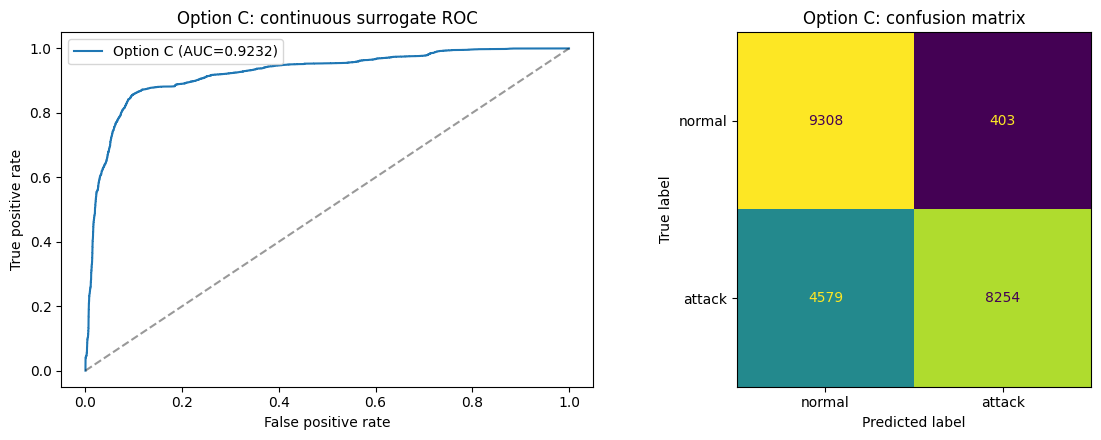

In [15]:
auc_c = roc_auc_score(y_test, y_proba_c)
accuracy_c = accuracy_score(y_test, y_pred_c)
teacher_mae = np.mean(np.abs(train_score_c - train_anomaly_score))
teacher_correlation = np.corrcoef(train_score_c, train_anomaly_score)[0, 1]

print(f"Training teacher-score MAE:         {teacher_mae:.6f}")
print(f"Training teacher-score correlation: {teacher_correlation:.6f}")
print(f"Training-only threshold:            {threshold_c:.6f}")
print(f"Option C ROC-AUC:                   {auc_c:.6f}")
print(f"Option C accuracy:                  {accuracy_c:.6f}\n")
print(classification_report(y_test, y_pred_c, target_names=["normal", "attack"]))

fpr_c, tpr_c, _ = roc_curve(y_test, y_proba_c)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr_c, tpr_c, label=f"Option C (AUC={auc_c:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="Option C: continuous surrogate ROC",
)
axes[0].legend()
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_c),
    display_labels=["normal", "attack"],
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Option C: confusion matrix")
plt.tight_layout()
plt.show()

### **Option D — Denoising autoencoder traffic filter**

Option D learns a compressed representation of normal network traffic and reconstructs it. Traffic with unusually large reconstruction error is treated as anomalous.

- The autoencoder is fitted only on normal `KDDTrain+` records.
- Numerical features are standardized using normal training traffic.
- Protocol, service and flag are one-hot encoded.
- A normal-only validation split provides early stopping and the detection threshold.
- `network_traffic_filter()` exposes the fitted model as a reusable batch or single-record traffic filter.

This is independent of the TabPFN teacher and provides a second fast anomaly signal for comparison.

In [16]:
AE_BATCH_SIZE = 1024
AE_MAX_EPOCHS = 60
AE_PATIENCE = 7
AE_LEARNING_RATE = 1e-3
AE_NOISE_STD = 0.03
AE_FALSE_POSITIVE_RATE = 0.05

# Reload raw categories because Option A ordinal-encoded train_df/test_df in place.
ae_train_df = pd.read_csv(TRAIN_FILE, names=COLUMN_NAMES)
ae_test_df = pd.read_csv(TEST_FILE, names=COLUMN_NAMES)
AE_NUMERIC_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]
normal_mask_train = (ae_train_df["label"] == "normal").to_numpy()

ae_scaler = StandardScaler()
ae_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ae_scaler.fit(ae_train_df.loc[normal_mask_train, AE_NUMERIC_COLS])
ae_encoder.fit(ae_train_df.loc[normal_mask_train, CATEGORICAL_COLS])


def transform_autoencoder_features(frame):
    numeric = ae_scaler.transform(frame[AE_NUMERIC_COLS]).astype(np.float32)
    categorical = ae_encoder.transform(frame[CATEGORICAL_COLS]).astype(np.float32)
    values = np.hstack([numeric, categorical]).astype(np.float32)
    return np.nan_to_num(values, nan=0.0, posinf=20.0, neginf=-20.0)


X_ae_normal = transform_autoencoder_features(
    ae_train_df.loc[normal_mask_train]
)
X_ae_test = transform_autoencoder_features(ae_test_df)

X_ae_fit, X_ae_val = train_test_split(
    X_ae_normal,
    test_size=0.15,
    random_state=RANDOM_STATE,
)
print("AE normal fit:", X_ae_fit.shape)
print("AE normal validation:", X_ae_val.shape)
print("AE full test:", X_ae_test.shape)

AE normal fit: (57241, 77)
AE normal validation: (10102, 77)
AE full test: (22544, 77)


In [17]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 96),
            nn.LayerNorm(96),
            nn.GELU(),
            nn.Linear(96, 32),
            nn.GELU(),
            nn.Linear(32, 8),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),
            nn.GELU(),
            nn.Linear(32, 96),
            nn.GELU(),
            nn.Linear(96, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def reconstruction_scores(model, values, batch_size=4096):
    model.eval()
    scores = []
    loader = DataLoader(
        TensorDataset(torch.from_numpy(values)),
        batch_size=batch_size,
        shuffle=False,
    )
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            reconstructed = model(batch)
            scores.append(
                torch.mean((reconstructed - batch) ** 2, dim=1).cpu().numpy()
            )
    return np.concatenate(scores)

#### **D1. Train the normal-traffic autoencoder**

In [18]:
%%time
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

autoencoder = DenoisingAutoencoder(X_ae_fit.shape[1]).to(DEVICE)
optimizer = torch.optim.AdamW(
    autoencoder.parameters(),
    lr=AE_LEARNING_RATE,
    weight_decay=1e-5,
)
loss_fn = nn.MSELoss()
fit_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_ae_fit)),
    batch_size=AE_BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
)

best_state = None
best_val_loss = np.inf
epochs_without_improvement = 0

for epoch in range(1, AE_MAX_EPOCHS + 1):
    autoencoder.train()
    running_loss = 0.0
    rows_in_epoch = 0
    for (batch,) in fit_loader:
        batch = batch.to(DEVICE, non_blocking=True)
        noisy_batch = batch + AE_NOISE_STD * torch.randn_like(batch)
        optimizer.zero_grad(set_to_none=True)
        reconstructed = autoencoder(noisy_batch)
        loss = loss_fn(reconstructed, batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(batch)
        rows_in_epoch += len(batch)

    val_scores = reconstruction_scores(autoencoder, X_ae_val)
    val_loss = float(val_scores.mean())
    train_loss = running_loss / rows_in_epoch
    print(
        f"epoch={epoch:02d} train_mse={train_loss:.6f} "
        f"val_mse={val_loss:.6f}"
    )

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = copy.deepcopy(autoencoder.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= AE_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

autoencoder.load_state_dict(best_state)
autoencoder.eval()

epoch=01 train_mse=0.417471 val_mse=0.426126
epoch=02 train_mse=0.296703 val_mse=0.355540
epoch=03 train_mse=0.221864 val_mse=0.286367
epoch=04 train_mse=0.174265 val_mse=0.262076
epoch=05 train_mse=0.153948 val_mse=0.247391
epoch=06 train_mse=0.137768 val_mse=0.232413
epoch=07 train_mse=0.121101 val_mse=0.220099
epoch=08 train_mse=0.107427 val_mse=0.212786
epoch=09 train_mse=0.098148 val_mse=0.204794
epoch=10 train_mse=0.090090 val_mse=0.200586
epoch=11 train_mse=0.083444 val_mse=0.195315
epoch=12 train_mse=0.078227 val_mse=0.193429
epoch=13 train_mse=0.074080 val_mse=0.186906
epoch=14 train_mse=0.070885 val_mse=0.186502
epoch=15 train_mse=0.067574 val_mse=0.183494
epoch=16 train_mse=0.065115 val_mse=0.182163
epoch=17 train_mse=0.061536 val_mse=0.177571
epoch=18 train_mse=0.059878 val_mse=0.182032
epoch=19 train_mse=0.057808 val_mse=0.176721
epoch=20 train_mse=0.055370 val_mse=0.182220
epoch=21 train_mse=0.052145 val_mse=0.176760
epoch=22 train_mse=0.050899 val_mse=0.174268
epoch=23 t

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=77, out_features=96, bias=True)
    (1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=96, out_features=32, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=32, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=96, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=96, out_features=77, bias=True)
  )
)

#### **D2. Training-calibrated filter, ROC and confusion matrix**

Normal-validation threshold: 0.064307
Option D ROC-AUC:            0.960155
Option D accuracy:           0.847055

              precision    recall  f1-score   support

      normal       0.77      0.91      0.84      9711
      attack       0.92      0.80      0.86     12833

    accuracy                           0.85     22544
   macro avg       0.85      0.86      0.85     22544
weighted avg       0.86      0.85      0.85     22544



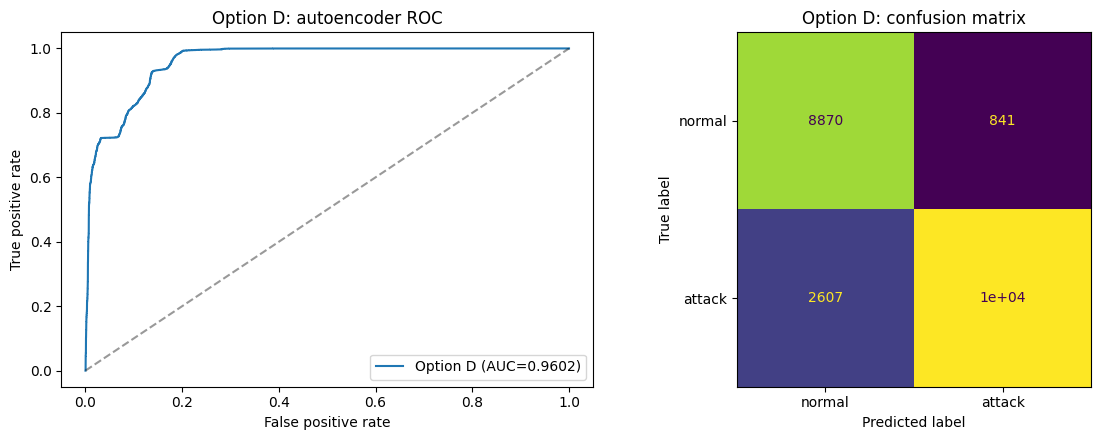

In [19]:
normal_validation_error = reconstruction_scores(autoencoder, X_ae_val)
test_reconstruction_error = reconstruction_scores(autoencoder, X_ae_test)

threshold_d = np.quantile(
    normal_validation_error,
    1 - AE_FALSE_POSITIVE_RATE,
)
y_pred_d = (test_reconstruction_error >= threshold_d).astype(np.int64)
auc_d = roc_auc_score(y_test, test_reconstruction_error)
accuracy_d = accuracy_score(y_test, y_pred_d)

print(f"Normal-validation threshold: {threshold_d:.6f}")
print(f"Option D ROC-AUC:            {auc_d:.6f}")
print(f"Option D accuracy:           {accuracy_d:.6f}\n")
print(classification_report(y_test, y_pred_d, target_names=["normal", "attack"]))

fpr_d, tpr_d, _ = roc_curve(y_test, test_reconstruction_error)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr_d, tpr_d, label=f"Option D (AUC={auc_d:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="Option D: autoencoder ROC",
)
axes[0].legend()
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_d),
    display_labels=["normal", "attack"],
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Option D: confusion matrix")
plt.tight_layout()
plt.show()

#### **Verified Option D benchmark**

On the full official split with the NVIDIA GB10:

- normal training records: **67,343**
- test records scored: **22,544 / 22,544**
- ROC-AUC: **0.960155**
- accuracy at the normal-validation threshold: **0.847055**
- selected epoch: **34** (early stopping completed at epoch 41)

The threshold was the 95th percentile of held-out normal reconstruction error; no test label was used for threshold selection.

#### **D3. Reusable network-traffic filter**

In [20]:
def network_traffic_filter(records):
    """Score raw NSL-KDD-format records and return recommended filter actions.

    `records` must be a pandas DataFrame containing FEATURE_COLS with raw
    protocol_type/service/flag values. The function performs no fitting.
    """
    missing = sorted(set(FEATURE_COLS) - set(records.columns))
    if missing:
        raise ValueError(f"Missing traffic features: {missing}")

    features = transform_autoencoder_features(records)
    anomaly_score = reconstruction_scores(autoencoder, features)
    is_anomaly = anomaly_score >= threshold_d

    return pd.DataFrame(
        {
            "anomaly_score": anomaly_score,
            "is_anomaly": is_anomaly,
            "action": np.where(is_anomaly, "block_or_review", "allow"),
        },
        index=records.index,
    )


# Example: filter the first five raw test records.
network_traffic_filter(ae_test_df.iloc[:5])

,anomaly_score,is_anomaly,action
0,0.728333,True,block_or_review
1,0.670006,True,block_or_review
2,0.006715,False,allow
3,0.063096,False,allow
4,0.197830,True,block_or_review


### **A/B/C/D ROC-AUC and filter analysis**

,option,training_signal,roc_auc,accuracy
0,A — supervised TabPFN,true normal/attack labels,0.967221,0.786684
3,D — denoising autoencoder,normal reconstruction error,0.960155,0.847055
2,C — continuous LightGBM surrogate,continuous Option B anomaly scores,0.923185,0.779010
1,B — TabPFN anomaly detector,normal density; labels only for feature screening,0.919240,0.832550


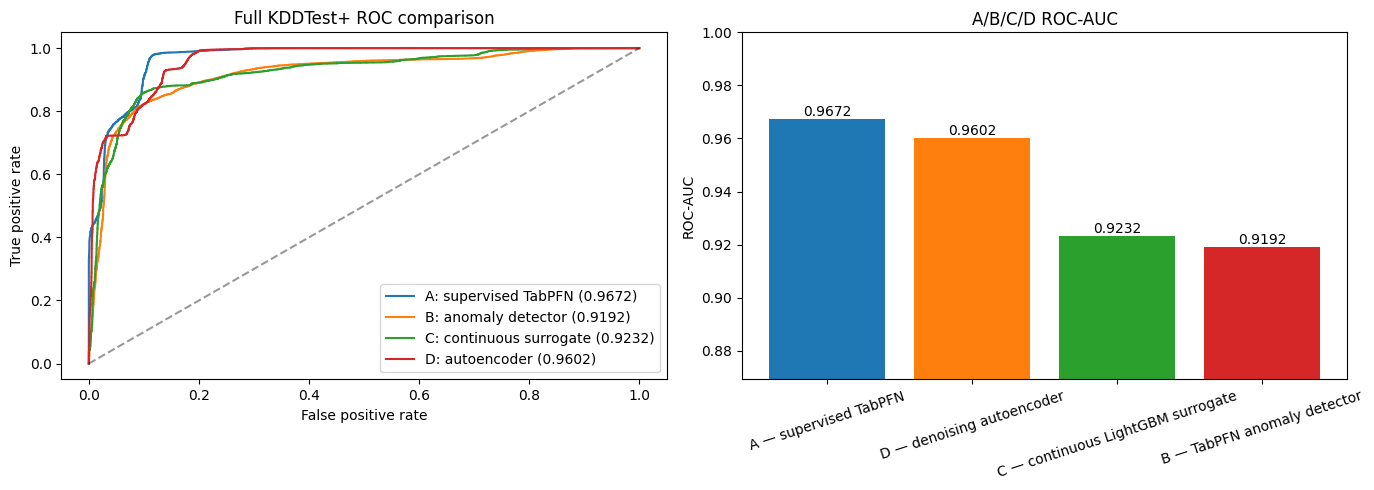

In [21]:
results = pd.DataFrame({
    "option": [
        "A — supervised TabPFN",
        "B — TabPFN anomaly detector",
        "C — continuous LightGBM surrogate",
        "D — denoising autoencoder",
    ],
    "training_signal": [
        "true normal/attack labels",
        "normal density; labels only for feature screening",
        "continuous Option B anomaly scores",
        "normal reconstruction error",
    ],
    "roc_auc": [test_auc, auc_b, auc_c, auc_d],
    "accuracy": [test_accuracy, accuracy_b, accuracy_c, accuracy_d],
}).sort_values("roc_auc", ascending=False)
display(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, label=f"A: supervised TabPFN ({test_auc:.4f})")
axes[0].plot(fpr_b, tpr_b, label=f"B: anomaly detector ({auc_b:.4f})")
axes[0].plot(fpr_c, tpr_c, label=f"C: continuous surrogate ({auc_c:.4f})")
axes[0].plot(fpr_d, tpr_d, label=f"D: autoencoder ({auc_d:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="Full KDDTest+ ROC comparison",
)
axes[0].legend()

bars = axes[1].bar(
    results["option"],
    results["roc_auc"],
    color=["C0", "C1", "C2", "C3"],
)
axes[1].bar_label(bars, fmt="%.4f")
axes[1].set_ylim(max(0, results["roc_auc"].min() - 0.05), 1.0)
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("A/B/C/D ROC-AUC")
axes[1].tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()

### **Deployment notes**

- Option C is the fastest teacher-derived filter and preserves Option B's continuous ranking.
- Option D is also fast after training and does not require attack labels, but reconstruction error can flag rare legitimate traffic.
- In production, use separate `alert` and `block` thresholds. The notebook's threshold targets a 5% false-positive rate on held-out normal training traffic.
- Do not automatically retrain the autoencoder on unverified production traffic; an attacker could poison the normal baseline.
- Measure p50/p95/p99 latency and process records in small batches where possible.
- High-confidence anomalies can be blocked or isolated. Borderline results should be alerted and sent asynchronously to the slower TabPFN Option B teacher.

### **Normal vs attack feature probability densities**

These paired plots compare the empirical feature distributions of normal and attack records in `KDDTrain+` and `KDDTest+`. To keep the figure readable, they show the eight highest-ranked numeric features with at least ten distinct values. KDE fitting uses a reproducible, class-balanced sample of at most 10,000 records per class and split. Each feature uses shared train/test limits covering its central 99% range so extreme NSL-KDD outliers do not compress the useful part of the density.

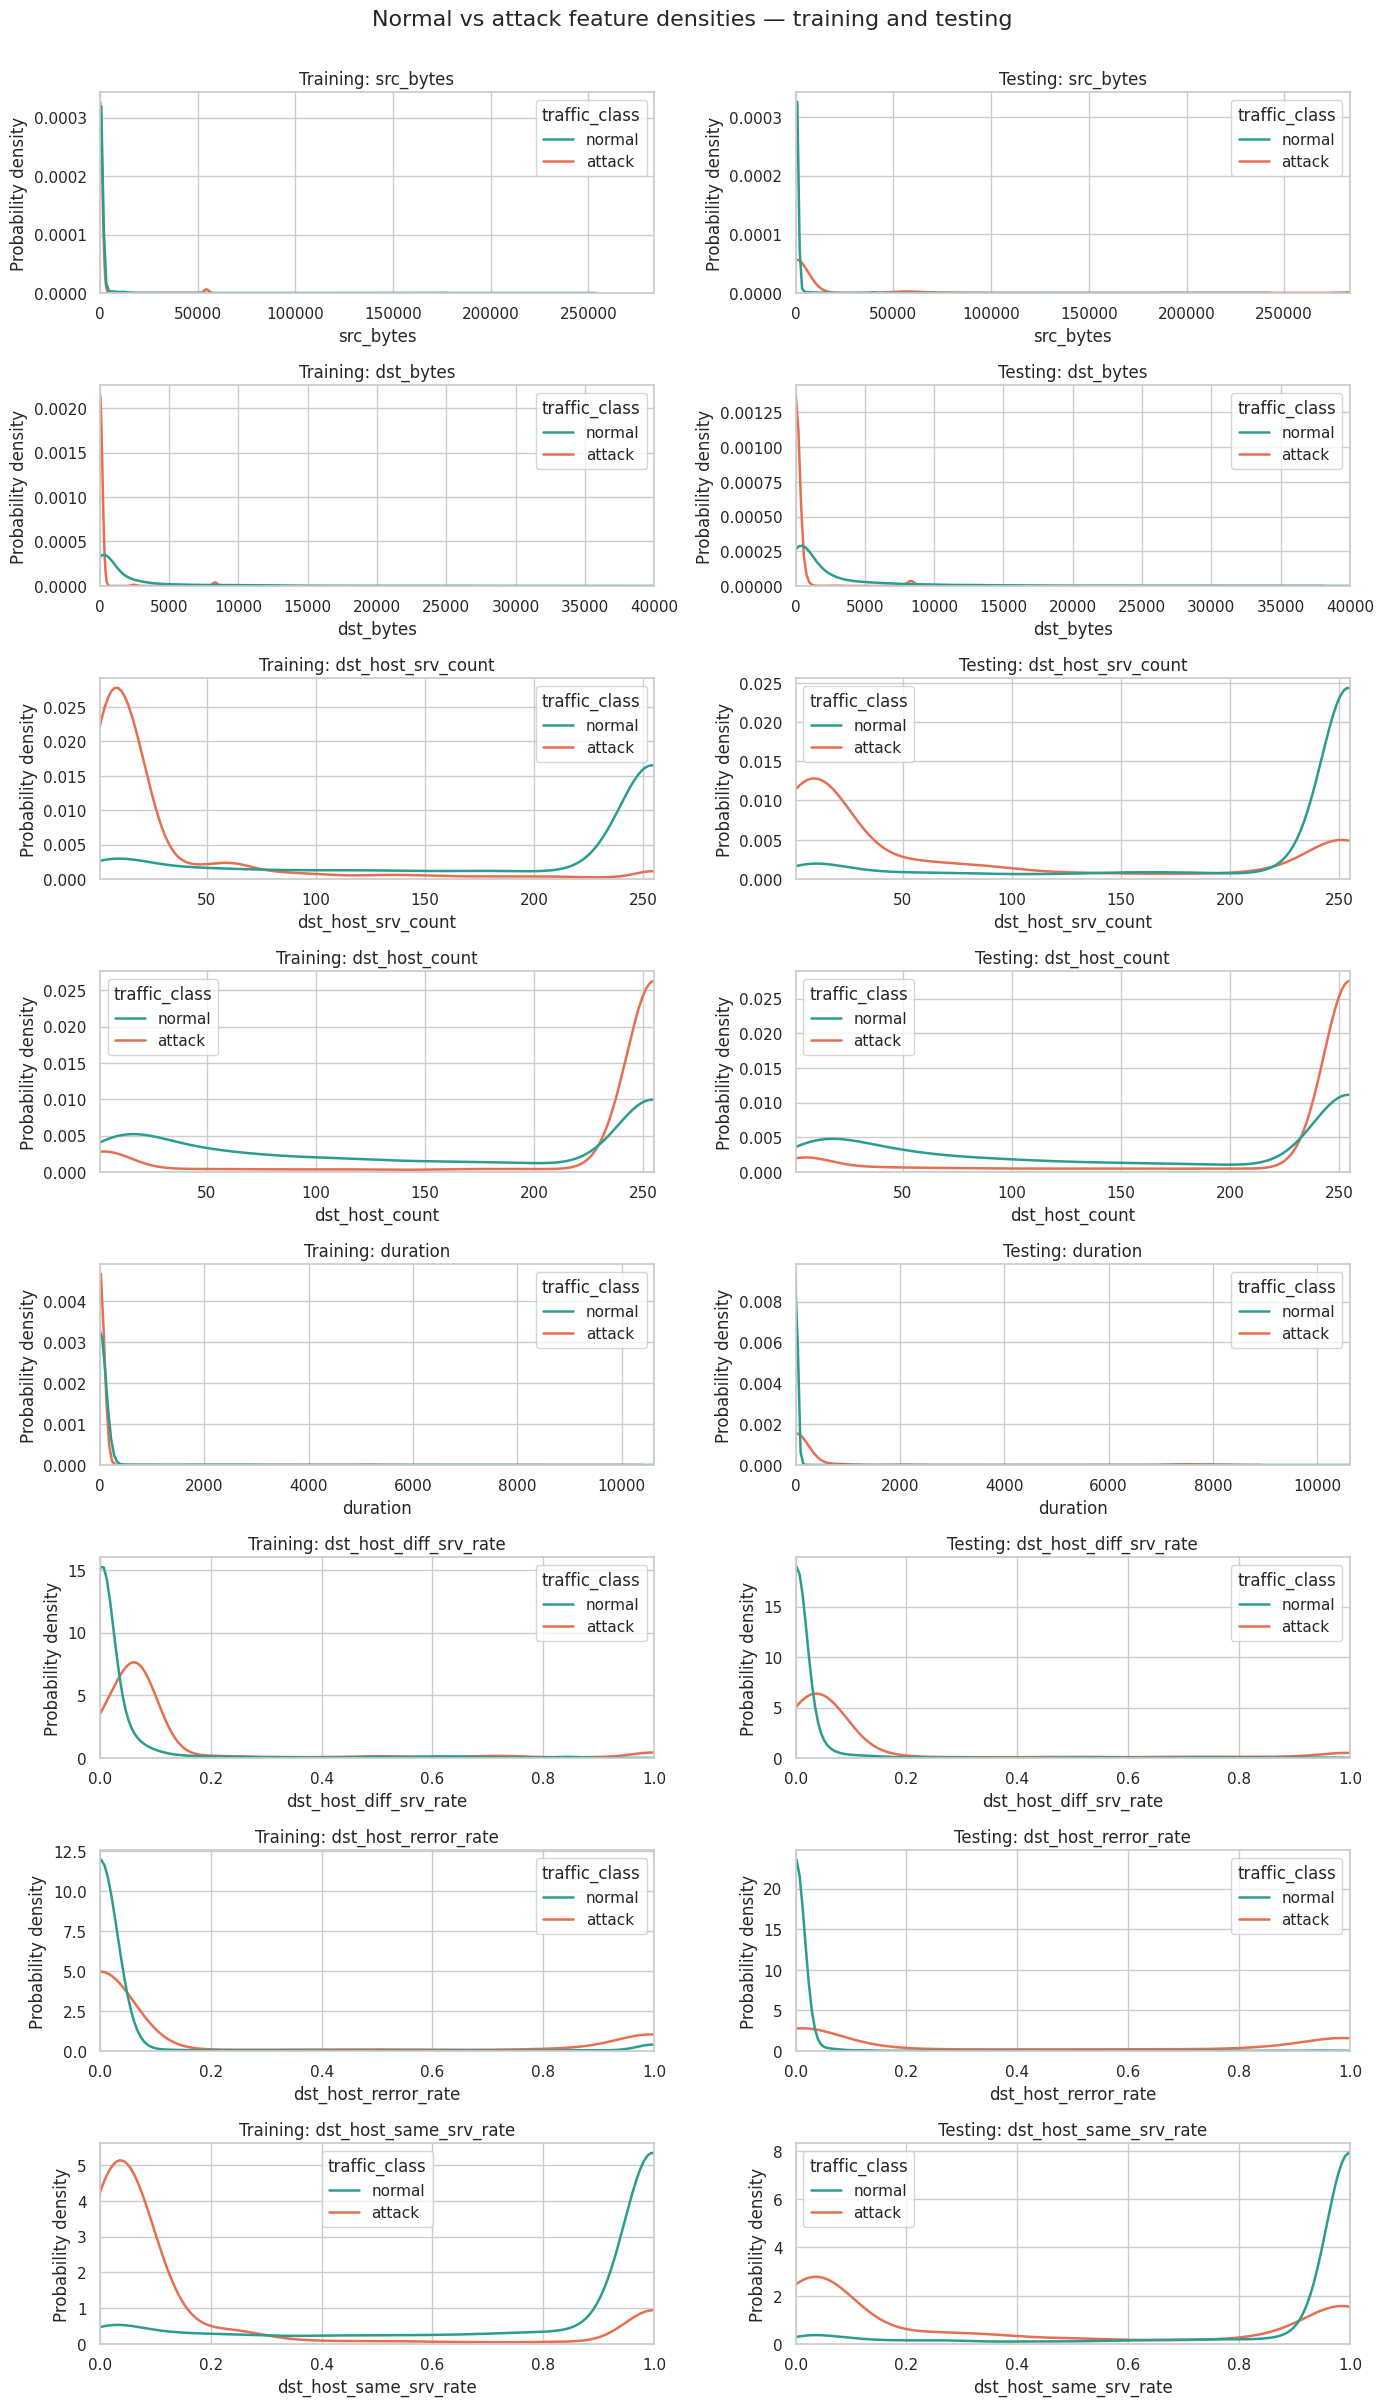

In [22]:
import seaborn as sns

PDF_SAMPLE_PER_CLASS = 10_000
PDF_FEATURE_COUNT = 8
pdf_rng = np.random.default_rng(RANDOM_STATE)

# Use raw frames so numeric features retain their original scales.
pdf_numeric_features = [
    feature for feature in feature_importance.index
    if feature not in CATEGORICAL_COLS
    and pd.concat([ae_train_df[feature], ae_test_df[feature]]).nunique() >= 10
][:PDF_FEATURE_COUNT]


def balanced_density_sample(frame, max_per_class, rng):
    parts = []
    binary_label = (frame["label"] != "normal").astype(np.int64)
    for class_id in (0, 1):
        indices = np.flatnonzero(binary_label.to_numpy() == class_id)
        if len(indices) > max_per_class:
            indices = rng.choice(indices, size=max_per_class, replace=False)
        part = frame.iloc[indices][pdf_numeric_features].copy()
        part["traffic_class"] = "attack" if class_id else "normal"
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


train_pdf = balanced_density_sample(ae_train_df, PDF_SAMPLE_PER_CLASS, pdf_rng)
test_pdf = balanced_density_sample(ae_test_df, PDF_SAMPLE_PER_CLASS, pdf_rng)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(
    len(pdf_numeric_features), 2,
    figsize=(14, 3.0 * len(pdf_numeric_features)),
    squeeze=False,
)
palette = {"normal": "#2a9d8f", "attack": "#e76f51"}

for row, feature in enumerate(pdf_numeric_features):
    pooled = pd.concat([train_pdf[feature], test_pdf[feature]], ignore_index=True)
    x_low, x_high = pooled.quantile([0.005, 0.995])
    if x_low == x_high:
        x_low, x_high = pooled.min(), pooled.max()

    for col, (split_name, density_data) in enumerate([
        ("Training", train_pdf),
        ("Testing", test_pdf),
    ]):
        ax = axes[row, col]
        visible = density_data[density_data[feature].between(x_low, x_high)]
        sns.kdeplot(
            data=visible,
            x=feature,
            hue="traffic_class",
            hue_order=["normal", "attack"],
            palette=palette,
            common_norm=False,
            fill=False,
            linewidth=1.8,
            warn_singular=False,
            ax=ax,
        )
        ax.set_xlim(x_low, x_high)
        ax.set_title(f"{split_name}: {feature}")
        ax.set_xlabel(feature)
        ax.set_ylabel("Probability density")

fig.suptitle(
    "Normal vs attack feature densities — training and testing",
    fontsize=16,
    y=1.002,
)
plt.tight_layout()
plt.show()

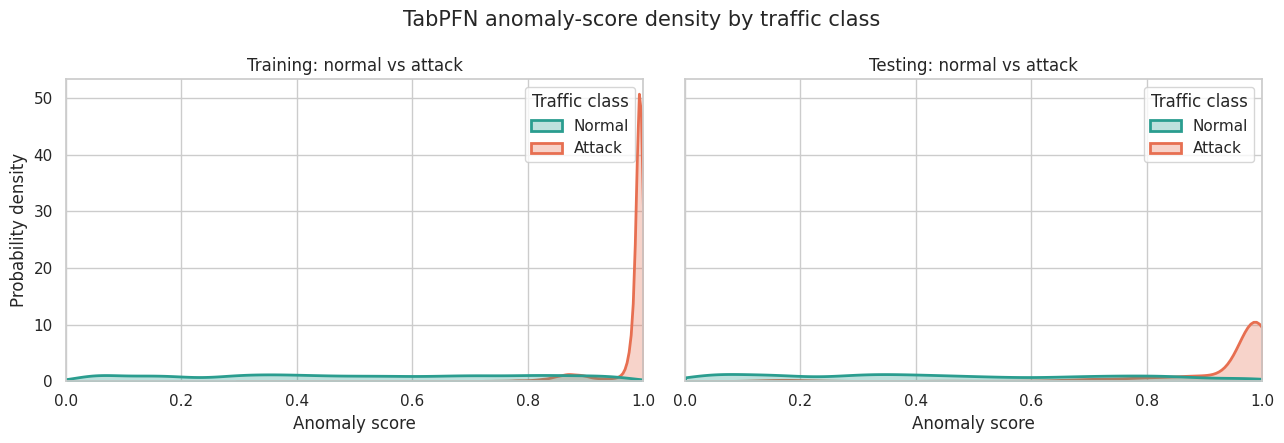

In [23]:
density_frames = {
    "Training": pd.DataFrame({
        "Anomaly score": train_anomaly_score,
        "Traffic class": pd.Series(y_train).map({0: "Normal", 1: "Attack"}),
    }),
    "Testing": pd.DataFrame({
        "Anomaly score": test_anomaly_score,
        "Traffic class": pd.Series(y_test).map({0: "Normal", 1: "Attack"}),
    }),
}

palette = {"Normal": "#2a9d8f", "Attack": "#e76f51"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

for ax, (split, frame) in zip(axes, density_frames.items()):
    sns.kdeplot(
        data=frame,
        x="Anomaly score",
        hue="Traffic class",
        hue_order=["Normal", "Attack"],
        palette=palette,
        common_norm=False,
        fill=True,
        alpha=0.30,
        linewidth=2,
        clip=(0, 1),
        warn_singular=False,
        ax=ax,
    )
    ax.set_xlim(0, 1)
    ax.set_title(f"{split}: normal vs attack")
    ax.set_ylabel("Probability density")

fig.suptitle("TabPFN anomaly-score density by traffic class", fontsize=15)
plt.tight_layout()
plt.show()

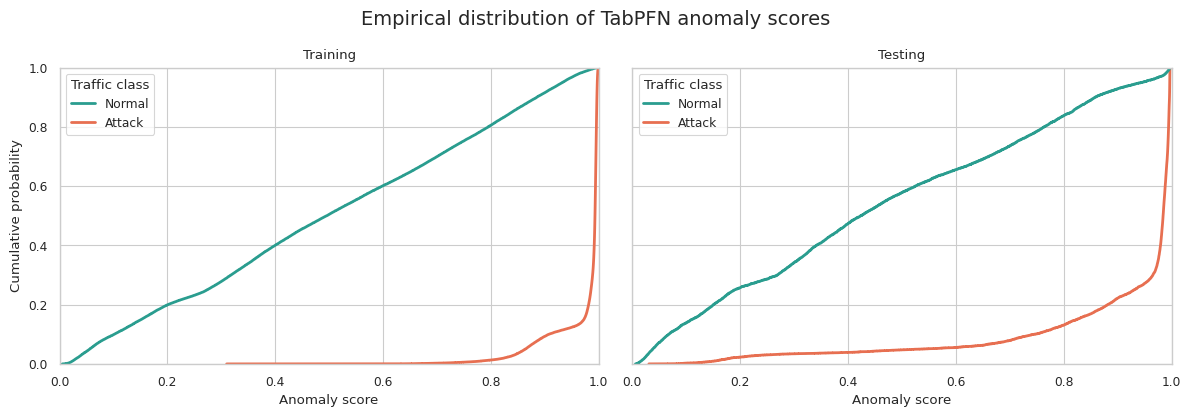

In [24]:
# Empirical CDFs reveal tail separation more clearly than KDEs.
import seaborn as sns

ecdf_data = pd.concat([
    pd.DataFrame({"Anomaly score": train_anomaly_score, "Traffic class": pd.Series(y_train).map({0: "Normal", 1: "Attack"}), "Split": "Training"}),
    pd.DataFrame({"Anomaly score": test_anomaly_score, "Traffic class": pd.Series(y_test).map({0: "Normal", 1: "Attack"}), "Split": "Testing"}),
], ignore_index=True)

sns.set_theme(style="whitegrid", context="paper")
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True, sharey=True)
for axis, split in zip(axes, ["Training", "Testing"]):
    sns.ecdfplot(data=ecdf_data[ecdf_data["Split"] == split], x="Anomaly score", hue="Traffic class", hue_order=["Normal", "Attack"], palette={"Normal": "#2a9d8f", "Attack": "#e76f51"}, linewidth=2, ax=axis)
    axis.set(title=split, xlim=(0, 1), ylabel="Cumulative probability")
figure.suptitle("Empirical distribution of TabPFN anomaly scores", fontsize=14)
plt.tight_layout()
plt.show()

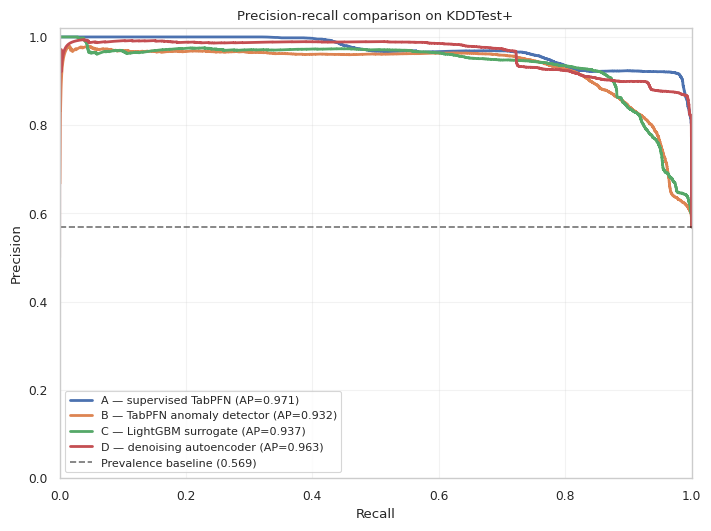

In [25]:
from sklearn.metrics import average_precision_score, precision_recall_curve

model_scores = {
    "A — supervised TabPFN": y_proba,
    "B — TabPFN anomaly detector": test_anomaly_score,
    "C — LightGBM surrogate": y_proba_c,
    "D — denoising autoencoder": test_reconstruction_error,
}

plt.figure(figsize=(7.2, 5.4))
for name, scores in model_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    average_precision = average_precision_score(y_test, scores)
    plt.plot(recall, precision, linewidth=2, label=f"{name} (AP={average_precision:.3f})")
attack_prevalence = float(y_test.mean())
plt.axhline(attack_prevalence, color="black", linestyle="--", alpha=0.55, label=f"Prevalence baseline ({attack_prevalence:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-recall comparison on KDDTest+")
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.legend(fontsize=8); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

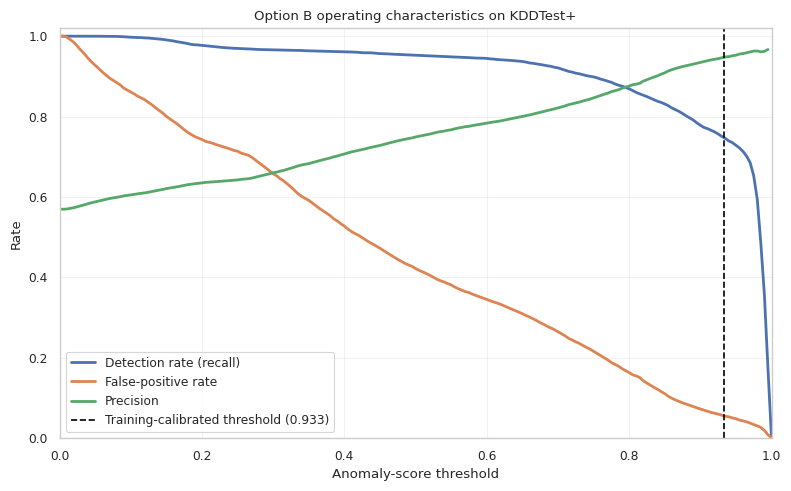

In [26]:
# Detection/false-alarm trade-off across Option B operating thresholds.
operating_thresholds = np.linspace(0, 1, 201)
false_positive_rates, detection_rates, precisions = [], [], []
for threshold in operating_thresholds:
    predicted_attack = test_anomaly_score >= threshold
    false_positive_rates.append(predicted_attack[y_test == 0].mean())
    detection_rates.append(predicted_attack[y_test == 1].mean())
    precisions.append(y_test[predicted_attack].mean() if predicted_attack.any() else np.nan)

figure, axis = plt.subplots(figsize=(8, 5))
axis.plot(operating_thresholds, detection_rates, label="Detection rate (recall)", linewidth=2)
axis.plot(operating_thresholds, false_positive_rates, label="False-positive rate", linewidth=2)
axis.plot(operating_thresholds, precisions, label="Precision", linewidth=2)
axis.axvline(anomaly_threshold, color="black", linestyle="--", label=f"Training-calibrated threshold ({anomaly_threshold:.3f})")
axis.set(xlabel="Anomaly-score threshold", ylabel="Rate", title="Option B operating characteristics on KDDTest+", xlim=(0, 1), ylim=(0, 1.02))
axis.legend(); axis.grid(alpha=0.25)
plt.tight_layout(); plt.show()

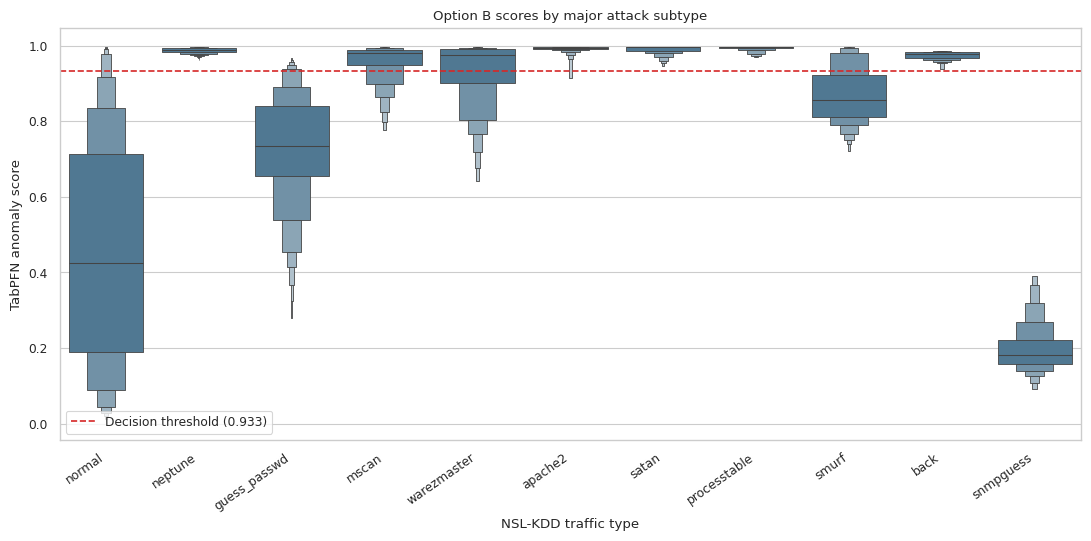

In [27]:
# Score distributions for normal traffic and the most frequent test attack types.
subtype_scores = pd.DataFrame({"Traffic type": test_df["label"].astype(str).to_numpy(), "Anomaly score": test_anomaly_score})
attack_order = subtype_scores.loc[subtype_scores["Traffic type"] != "normal", "Traffic type"].value_counts().head(10).index.tolist()
display_order = ["normal"] + attack_order
plot_data = subtype_scores[subtype_scores["Traffic type"].isin(display_order)]

plt.figure(figsize=(11, 5.5))
sns.boxenplot(data=plot_data, x="Traffic type", y="Anomaly score", order=display_order, color="#457b9d", showfliers=False)
plt.axhline(anomaly_threshold, color="#d62828", linestyle="--", label=f"Decision threshold ({anomaly_threshold:.3f})")
plt.xlabel("NSL-KDD traffic type"); plt.ylabel("TabPFN anomaly score")
plt.title("Option B scores by major attack subtype")
plt.xticks(rotation=35, ha="right"); plt.legend()
plt.tight_layout(); plt.show()

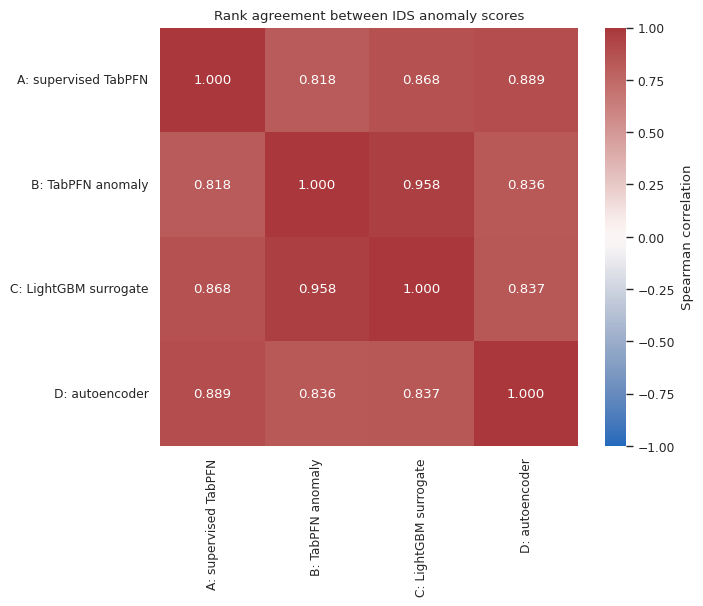

In [28]:
# Agreement among models: Spearman correlation is robust to score scaling.
score_table = pd.DataFrame({
    "A: supervised TabPFN": y_proba,
    "B: TabPFN anomaly": test_anomaly_score,
    "C: LightGBM surrogate": y_proba_c,
    "D: autoencoder": test_reconstruction_error,
})
score_correlation = score_table.corr(method="spearman")

plt.figure(figsize=(7.2, 6))
sns.heatmap(score_correlation, annot=True, fmt=".3f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True, cbar_kws={"label": "Spearman correlation"})
plt.title("Rank agreement between IDS anomaly scores")
plt.tight_layout(); plt.show()

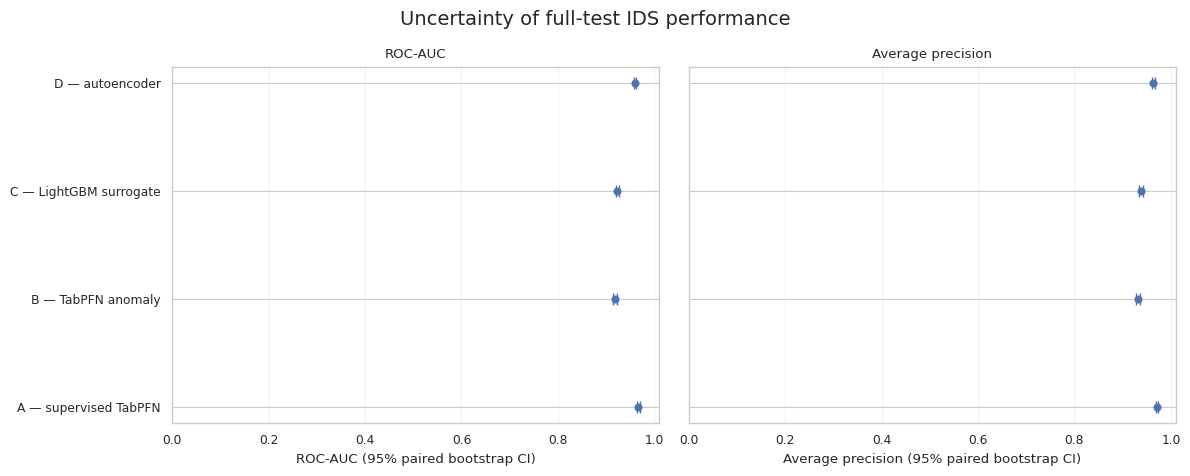

,Model,Metric,Estimate,Low,High
0,A — supervised TabPFN,ROC-AUC,0.967199,0.965056,0.969300
1,A — supervised TabPFN,Average precision,0.970711,0.968812,0.972765
2,B — TabPFN anomaly,ROC-AUC,0.919056,0.915291,0.922895
3,B — TabPFN anomaly,Average precision,0.931865,0.927031,0.936298
4,C — LightGBM surrogate,ROC-AUC,0.923036,0.919542,0.926688
5,C — LightGBM surrogate,Average precision,0.937216,0.933046,0.941181
6,D — autoencoder,ROC-AUC,0.960167,0.957606,0.962268
7,D — autoencoder,Average precision,0.963491,0.960224,0.966350


In [29]:
# Paired stratified bootstrap confidence intervals for ROC-AUC and AP.
from sklearn.metrics import average_precision_score, roc_auc_score

BOOTSTRAP_REPEATS = 1000
bootstrap_rng = np.random.default_rng(42)
model_scores = {
    "A — supervised TabPFN": np.asarray(y_proba),
    "B — TabPFN anomaly": np.asarray(test_anomaly_score),
    "C — LightGBM surrogate": np.asarray(y_proba_c),
    "D — autoencoder": np.asarray(test_reconstruction_error),
}
y_boot = np.asarray(y_test)
class_indices = [np.flatnonzero(y_boot == class_id) for class_id in (0, 1)]
records = []
for repeat in range(BOOTSTRAP_REPEATS):
    sampled = np.concatenate([bootstrap_rng.choice(idx, len(idx), replace=True) for idx in class_indices])
    for model, scores in model_scores.items():
        records.append({"Model": model, "ROC-AUC": roc_auc_score(y_boot[sampled], scores[sampled]), "Average precision": average_precision_score(y_boot[sampled], scores[sampled])})
bootstrap_results = pd.DataFrame(records)
summary = []
for model, group in bootstrap_results.groupby("Model", sort=False):
    for metric in ["ROC-AUC", "Average precision"]:
        low, estimate, high = np.quantile(group[metric], [0.025, 0.5, 0.975])
        summary.append({"Model": model, "Metric": metric, "Estimate": estimate, "Low": low, "High": high})
summary = pd.DataFrame(summary)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
order = list(model_scores)
for axis, metric in zip(axes, ["ROC-AUC", "Average precision"]):
    view = summary[summary["Metric"] == metric].set_index("Model").loc[order].reset_index()
    y_position = np.arange(len(view))
    axis.errorbar(view["Estimate"], y_position, xerr=[view["Estimate"] - view["Low"], view["High"] - view["Estimate"]], fmt="o", capsize=4, linewidth=1.8)
    axis.set(xlabel=f"{metric} (95% paired bootstrap CI)", yticks=y_position, yticklabels=order, xlim=(0, 1.01), title=metric)
    axis.grid(axis="x", alpha=0.25)
figure.suptitle("Uncertainty of full-test IDS performance", fontsize=14)
plt.tight_layout(); plt.show()
display(summary)

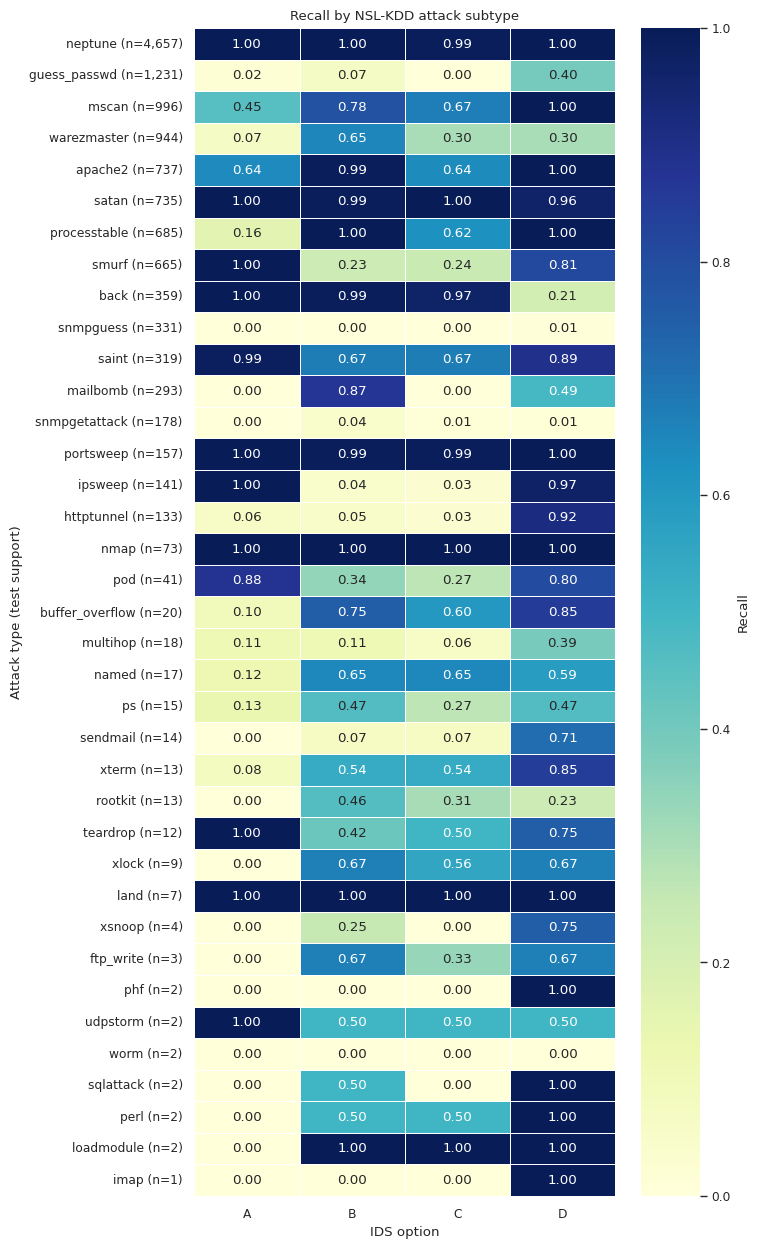

In [30]:
# Per-attack recall heatmap; row labels include test-set support.


predictions = {
    "A": np.asarray(y_proba) >= 0.5,
    "B": np.asarray(test_anomaly_score) >= anomaly_threshold,
    "C": np.asarray(y_proba_c) >= threshold_c,
    "D": np.asarray(test_reconstruction_error) >= threshold_d,
}
attack_labels = test_df["label"].astype(str).to_numpy()
attack_types, support = np.unique(attack_labels[attack_labels != "normal"], return_counts=True)
attack_types = attack_types[np.argsort(support)[::-1]]
recall_table = pd.DataFrame(index=attack_types, columns=predictions, dtype=float)
for attack_type in attack_types:
    mask = attack_labels == attack_type
    for model, predicted in predictions.items():
        recall_table.loc[attack_type, model] = predicted[mask].mean()
row_support = pd.Series({name: int((attack_labels == name).sum()) for name in attack_types})
recall_table.index = [f"{name} (n={row_support[name]:,})" for name in attack_types]
height = max(6, 0.34 * len(recall_table))
plt.figure(figsize=(7.5, height))
sns.heatmap(recall_table, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, cbar_kws={"label": "Recall"}, linewidths=0.4)
plt.xlabel("IDS option"); plt.ylabel("Attack type (test support)")
plt.title("Recall by NSL-KDD attack subtype")
plt.tight_layout(); plt.show()

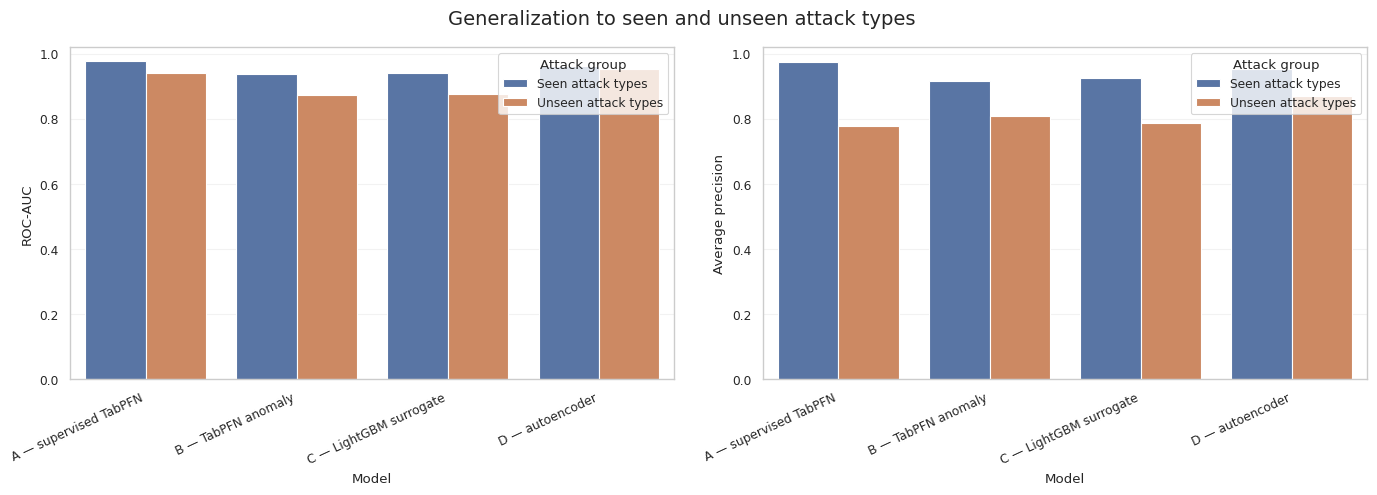

,Attack group,Model,ROC-AUC,Average precision
0,Seen attack types,A — supervised TabPFN,0.978068,0.974856
1,Seen attack types,B — TabPFN anomaly,0.938738,0.914951
2,Seen attack types,C — LightGBM surrogate,0.942272,0.924545
3,Seen attack types,D — autoencoder,0.963373,0.954140
4,Unseen attack types,A — supervised TabPFN,0.940947,0.777357
5,Unseen attack types,B — TabPFN anomaly,0.872015,0.807275
6,Unseen attack types,C — LightGBM surrogate,0.876955,0.788329
7,Unseen attack types,D — autoencoder,0.952361,0.869035


In [31]:
# Generalization to attack names seen and unseen during training.

from sklearn.metrics import average_precision_score, roc_auc_score

scores_by_model = {
    "A — supervised TabPFN": np.asarray(y_proba),
    "B — TabPFN anomaly": np.asarray(test_anomaly_score),
    "C — LightGBM surrogate": np.asarray(y_proba_c),
    "D — autoencoder": np.asarray(test_reconstruction_error),
}
test_names = test_df["label"].astype(str).to_numpy()
normal = np.asarray(y_test) == 0
seen_attack = (np.asarray(y_test) == 1) & np.isin(test_names, list(train_attack_types))
unseen_attack = (np.asarray(y_test) == 1) & ~np.isin(test_names, list(train_attack_types))
groups = {"Seen attack types": normal | seen_attack, "Unseen attack types": normal | unseen_attack}
rows = []
for group_name, mask in groups.items():
    for model, scores in scores_by_model.items():
        rows.append({"Attack group": group_name, "Model": model, "ROC-AUC": roc_auc_score(np.asarray(y_test)[mask], scores[mask]), "Average precision": average_precision_score(np.asarray(y_test)[mask], scores[mask])})
generalization = pd.DataFrame(rows)
figure, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for axis, metric in zip(axes, ["ROC-AUC", "Average precision"]):
    sns.barplot(data=generalization, x="Model", y=metric, hue="Attack group", ax=axis)
    axis.set_ylim(0, 1.02); axis.tick_params(axis="x", rotation=25); axis.grid(axis="y", alpha=0.25)
    for label in axis.get_xticklabels(): label.set_ha("right")
figure.suptitle("Generalization to seen and unseen attack types", fontsize=14)
plt.tight_layout(); plt.show()
display(generalization)

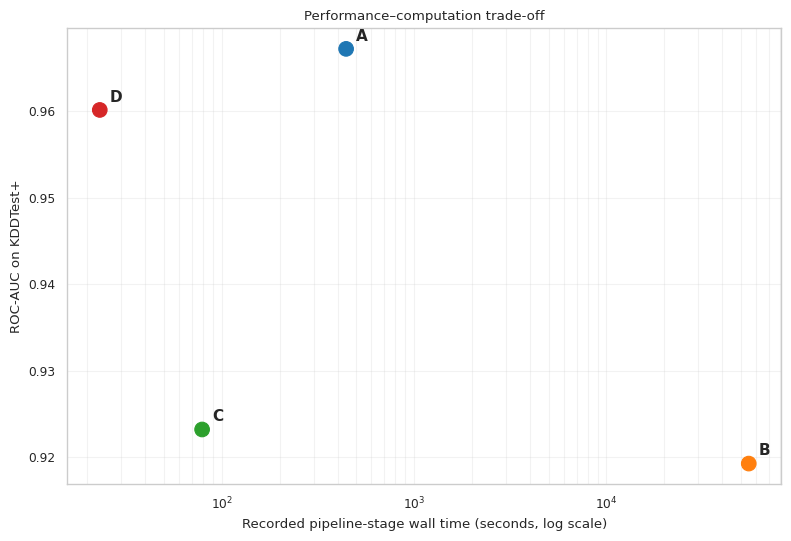

,Model,ROC-AUC,Recorded stage wall time (s)
0,A — supervised TabPFN,0.967221,443.0
1,B — TabPFN anomaly,0.919240,54977.0
2,C — LightGBM surrogate,0.923185,79.0
3,D — autoencoder,0.960155,23.2


In [32]:
# Accuracy-cost Pareto view using wall times recorded by %%time in the pipeline.

pareto = pd.DataFrame({
    "Model": ["A — supervised TabPFN", "B — TabPFN anomaly", "C — LightGBM surrogate", "D — autoencoder"],
    "ROC-AUC": [test_auc, auc_b, auc_c, auc_d],
    "Recorded stage wall time (s)": [443.0, 54977.0, 79.0, 23.2],
    "Marker": ["A", "B", "C", "D"],
})
# Times cover each notebook stage as instrumented and are not pure inference benchmarks.
figure, axis = plt.subplots(figsize=(8, 5.5))
axis.scatter(pareto["Recorded stage wall time (s)"], pareto["ROC-AUC"], s=110, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
for _, row in pareto.iterrows():
    axis.annotate(row["Marker"], (row["Recorded stage wall time (s)"], row["ROC-AUC"]), xytext=(7, 6), textcoords="offset points", fontsize=11, weight="bold")
axis.set_xscale("log")
axis.set(xlabel="Recorded pipeline-stage wall time (seconds, log scale)", ylabel="ROC-AUC on KDDTest+", title="Performance–computation trade-off")
axis.grid(True, which="both", alpha=0.25)
plt.tight_layout(); plt.show()
display(pareto.drop(columns="Marker"))